# Bank Product Recommendation System using Clustering
### Advanced Machine Learning (Project 2)
**Authors:** Otari Samadashvili and Nana Jaoshvili  
**Date:** 11.01.2026.

---

## Introduction

### Project Motivation

In the modern financial services sector, banks and fintech organizations increasingly rely on data‑driven systems to personalize customer interactions and optimize product recommendations. The rapid advancements in open banking, digital channels, and advanced analytics provide access to customers' financial data, enabling analysts to use this  complex information and convert it into interpretable outputs for better decision-making and strategy planning. Traditional product recommendation systems in banking often depend on explicit feedback or historical product uptake, which is limited, sparse, and difficult to obtain due to confidentiality constraints. As a result, many financial institutions seek data‑centric approaches that can infer customer needs indirectly from available behavioral, demographic, and financial indicators.

Clustering‑based segmentation offers a promising solution to this problem. By grouping customers with similar financial characteristics, banks can tailor their financial products to each cluster without requiring data for customer preferences. Segments interpretation enhances recommendation precision and also aligns with compliance and transparency requirements in financial decision‑making, making them valuable in both retail and corporate banking contexts.

This project applies unsupervised learning to develop a **Bank Product Recommendation System** using Clustering. Using the “Personal Finance ML Dataset,” which uses real‑world financial behaviors such as salary, savings, debt, and expenditure patterns. The system will identify meaningful customer segments and associate each with an optimal set of banking products. The project aims to demonstrate how a bank or fintech company could implement unsupervised learning for customer understanding, product strategy, and long‑term personalization. The project will also employ a Large Language Model (LLM)‑based agent, adapted from the Agent4Rec framework, to simulate user personas and qualitatively assess the relevance and diversity of cluster‑based recommendations, bridging the gap between quantitative analytics and human‑like evaluation.


### Project Objective

The main objective of this project is to design, implement, and evaluate an interpretable **clustering framework** that groups customers in segments by their financial behavior and recommends relevant banking products for each segment. The project aims to identify meaningful financial clusters within the dataset using unsupervised learning methods to represent distinct customer profiles; define product‑segment matches, linking each cluster to suitable bank product based on financial indicators and clustering insights; Evaluate cluster quality and recommendation relevance, through internal validation metrics (such as silhouette) and also using an **LLM‑based evaluation agent** inspired by Agent4Rec to mimic customer interpretation and feedback.

The overall objective of the project is to create a transparent and practical model that financial institutions could implement as a decision support tool or marketing tool to enhance product targeting, reduce customer churn, and strengthen personalization strategies. This notebook documents the end-to-end workflow from data preparation and feature extraction to model evaluation providing a simple recommendation system for bank products.

The project defines four core banking products that serve as target recommendations for the identified customer clusters, with each cluster interpreted as a client persona that is more likely to value specific offerings. The products include: Priority Secured Refinance that restructures expensive unsecured debt using existing deposits as collateral, with additional cash‑bonus incentives for passive clients; Streamline Consolidation Loan to unify debts into a lower fixed payment; Prestige Cash Rewards Visa to monetise the spending of active clients; Personal Credit Line for clients seeking flexible liquidity.



### Motivation for the Chosen Method:

Clustering was selected as the main method for the project as it enables unsupervised discovery of hidden structures in heterogeneous customer data where explicit labels or product choices are unavailable. Clustering provides a data‑driven way to approximate the patterns between customer behaviour and product recommendation. Clustering enhances interpretability and business usability, decision makers and marketing teams can directly examine cluster characteristics without requiring access to the underlying algorithms or customer identities, preserving transparency and data privacy.

To comprehensively capture different relationship patterns within financial data, the project initially tested several clustering algorithms with distinct theoretical assumptions but ultimately retained only the most suitable one. **K‑means clustering** was used as a natural baseline because of its scalability and clear interpretability, assigning customers to discrete segments based on proximity to cluster centroids. **Agglomerative hierarchical clustering** was then applied to explore nested relationships among customers. The analysis then focused on **HDBSCAN**, a hierarchical density‑based method that groups customers according to regions of high point density rather than simple distance, which is better suited to the irregular and heterogeneous structure of the financial data. 


To strengthen the system’s evaluation, the project will integrate a **Large Language Model (LLM)-based agent**, adapted from the Agent4Rec framework, as a qualitative and behavioral assessment tool. Traditional clustering validation metrics, such as Silhouette Score, measure internal cluster coherence but do not capture human‑like interpretation of recommendation relevance. An LLM agent can simulate realistic customer personas with contextual memory, financial reasoning, and preference attributes essential for assessing whether the cluster‑based product recommendations align with perceived customer needs. By interacting with cluster-generated product suggestions, the LLM agent can provide narrative, contextual, and emotional feedback, bridging quantitative segmentation with experiential evaluation. This hybrid evaluation approach combines  unsupervised learning with the interpretive capabilities of generative AI, ensuring that the recommendation outcomes are intuitively meaningful for decision-makers in the banking sector.  
  

    



## Literature Review

Prior work on **["customer segmentation in banking"](https://www.researchgate.net/publication/389352556_Customer_Segmentation_Using_K-Means_Clustering_for_Targeted_Marketing_in_Banking)** shows that unsupervised learning can clearly define behavioral groups depending on their behaviour that directly support marketing and product strategy. Mentioned bank customer segmentation study applies k-means clustering to demographic and financial variables such as age, income, balances, and loan status, and illustrates how clusters can be interpreted as distinct personas that naturally map to different products and communication strategies. This demonstrates a clear way from statistical segmentation to concrete business actions and provides a methodological support for this project. The project aims to cluster personal financial profiles into interpretable segments and then assign bank products to each group for better personalization and increased product sales.

**["The application of cluster analysis in optimizing financial product recommendation systems"](https://direct.ewa.pub/proceedings/aemps/article/view/22678/pdf)** is further emphasized in the reviewed conference paper. By comparing different clustering algorithms and showing that cluster-based recommendation improves match quality and customer satisfaction relative to non-segmented baselines, the authors substantiate the value of a “cluster-then-recommend” pipeline. This supports the methodological choice in this project to use unsupervised segmentation as a first step before defining and evaluating rule-based or model-based bank product recommendations per cluster.

Finally, the literature on **["large language model based agents for recommendation"](https://arxiv.org/abs/2310.10108)** motivates the use of an LLM agent as an evaluation layer for the proposed system. The Agent4Rec framework introduces a recommendation simulator built with LLM-empowered generative agents that mimic users by maintaining profiles initialized from real datasets. It uses memory modules that store factual and emotional data and action modules that focus on customer behavior and responsiveness to previous recommendations. This agent architecture supports evaluation beyond static offline metrics by providing interactive feedback that approximates realistic online behavior and longer-term engagement. For this project, Agent4Rec offers a conceptual and technical justification for using an LLM-based agent to play the role of different financial client personas, assess cluster-based bank product suggestions, and surface qualitative signals such as relevance and diversity, thus enriching the evaluation of the clustering-based recommendation system.







## Dataset Description and Preprocessing

The project uses the **“Personal Finance ML Dataset”** from Kaggle for retail banking customers’ financial profiles. The dataset is designed for machine learning applications in personal finance and combines demographic attributes, financial indicators, loan characteristics, and credit‑related ratios. Each row corresponds to a unique synthetic individual with distinct income levels and behavioral patterns. The data was generated from statistical distributions and realistic assumptions to approximate global financial trends while avoiding privacy concerns. In addition, UCI **"Bank Marketing dataset"** was incorporated to simulate and enrich certain campaign and product related features, enabling more realistic modeling of customer responsiveness and product uptake behavior.  
  

The main variables of the dataset can be grouped into two key categories. **Demographic variables** include `age`, `gender`, `marital_status`, `education_level`, `employment_status`, and `job_title`, which provide contextual information about each client’s life stage and socio‑economic status. **Financial indicators** include `savings_usd`, `deposit_interest_rate`, `has_loan`, `loan_type`, `loan_amount`, `debt_to_income_ratio`, and `savings_to_income_ratio`, capturing liquidity, behaviour and clients' existing relationships with the bank. The combined dataset includes both retail and premium customers, though the latter are later excluded from the core analysis to focus on the mass‑market segment relevant for standardized product recommendations.


### Data Exploration and Cleaning

The data exploration phase first focused on understanding the structure and quality of all available variables. We inspected central patterns, dispersion, and distribution shapes for financial variables such as income, savings_usd, loan_amount, and ratio features, while bar plots and frequency tables were used for categorical demographics and product indicators. This step helped identify missing values, outliers (e.g. extreme incomes or savings), potential errors, and abnormal patterns such as negative or implausible financial amounts, which informed subsequent cleaning decisions and ensured that later clustering would be conducted without any disruptions.  


To align the dataset with a realistic retail‑banking use case, a series of business‑driven filtering steps was applied. ***Premium customers*** with monthly income above 8,000 USD were excluded, as such customers are typically handled by dedicated premium banking services rather than mass retail segment department. Additionally, ***low-income clients*** or no income clients with low or no savings were removed, as they do not qualify for the types of savings or investment offers considered in this project. In addition, ***purely demographic variables*** such as age, marital status, and profession were dropped from the clustering feature set after inspection, since the financial indicators alone were deemed sufficient for product recommendation and provided clearer, more directly interpretable signals for segmentation. ***Duplicate records***, if present, were removed to avoid biasing the clustering results.  


Several continuous variables exhibited strong skewness and heavy tails, requiring ***distributional transformations*** before clustering. For selected features and ratios, including `loan_amount`, `loan_interest_rate`, and related financial quantities, the **Yeo-Johnson Transformation** was applied to stabilize variance and make distributions more symmetric without requiring strictly positive values. After transformation, the original raw versions of these variables were dropped from the modeling feature matrix to avoid redundancy and potential numerical instability, while still preserving their informational content in a more well‑behaved form.  


For variables with ***multimodal behavior***, more advanced modeling was applied. In particular, a **Gaussian Mixture Model (GMM)** with two components was fitted to the engineered `responsiveness_rate` (derived from campaign behavior) and to `deposit_interest_rate`, capturing distinct modes, for responsiveness "low" vs "high" and for deposit rate four levels going from "very low" to "very high" levels to use as features for clustering. The mixture assignments and probabilities provided a richer representation of these variables than a single scalar value, allowing the clustering algorithms to differentiate between qualitatively different behavioral regimes within the same numeric range.

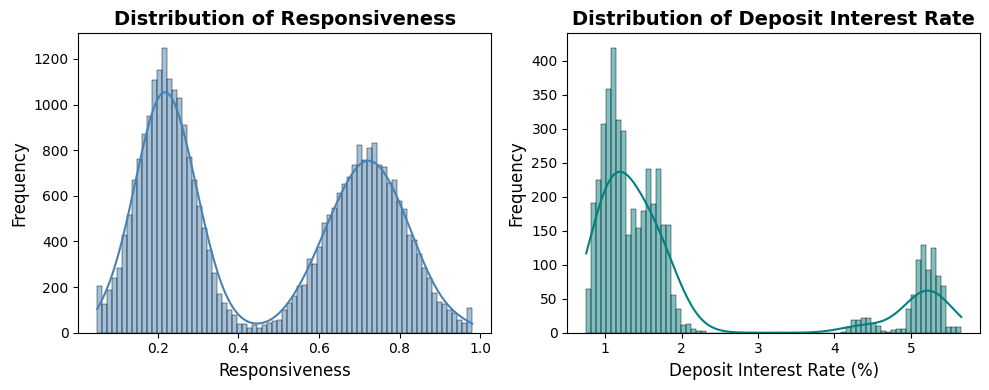
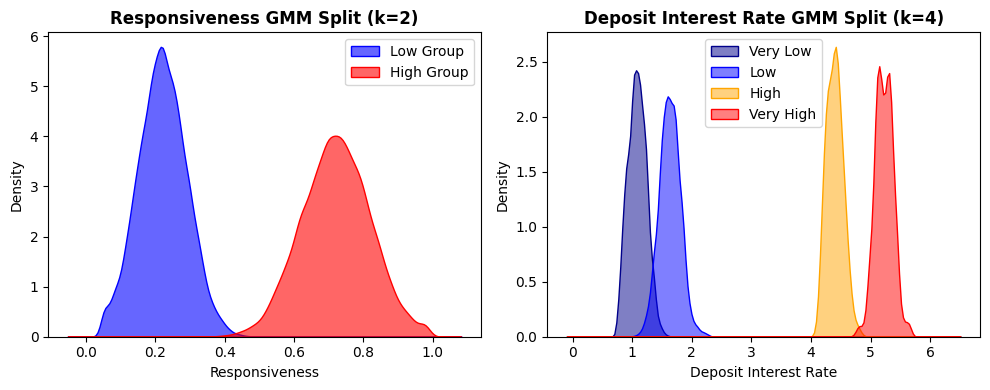  
*Figure 1: Multimodal features before and after GMM transofmation*

### Feature Engineering

A key engineered feature in this project is the **`responsiveness_rate`**, which aims to summarize how actively a client reacts to marketing campaigns. Using information derived and simulated from the combined personal finance and bank marketing datasets, previous campaign interactions were encoded in terms of whether the client was contacted, whether they responded, and whether they ultimately accepted or purchased the proposed product. These signals were aggregated into a numeric responsiveness score, which acts as a compact behavioral indicator. Higher values correspond to clients who are more likely to open, consider, and adopt offers. This feature is particularly useful for bank product recommendation, as it helps distinguish between otherwise similar financial profiles that differ in their propensity to engage with marketing communications. 

A second engineered variable is **`borrowing_power`** representing loan limit capacity. It approximates how much additional credit a client could reasonably borrow at the moment. This measure was constructed by estimating a `loan_limit` based on `credit_score`, `income`, `savings`, and `risk_factors`, and then subtracting the client’s current `loan_amount`. The result was further normalized using the **Yeo-Johnson transformation** to reduce skewness and make it more amenable to clustering. For interpretability in downstream analysis, borrowing power was also binarized into a yes/no indicator reflecting whether the client effectively has capacity to borrow more. This feature provides direct insight into the potential for cross‑selling or upselling credit products within each segment, complementing the variables focused on saving patterns.  


A third added feature is **`has_deposit`**, which indicates whether the client already holds an active deposit product with the bank. This binary flag is taken directly from the UCI dataset’s product indicators and serves as a simple but informative variable. In the context of cluster‑based recommendation, this feature helps differentiate between segments that are new to savings and those that already use deposit products, supporting strategies such as promoting initial savings accounts for non‑holders or offering more advanced or higher‑yield products to existing deposit customers.


## Clustering Results

The project evaluated several clustering algorithms, using grid search to optimize hyperparameters and identify meaningful customer segments based on financial behavior and product usage.  
The first method tested was **k‑means clustering**, a centroid‑based algorithm that partitions observations into k clusters by minimizing within‑cluster variance. On this data, k‑means produced unstable, poorly separated clusters, largely because the financial data contained complex shapes and binary distributions that violate k‑means' spherical‑cluster assumptions.

**HDBSCAN** (Hierarchical Density‑Based Spatial Clustering of Applications with Noise) was initially favored for its ability to handle irregular cluster shapes and varying densities. It successfully identified high‑density regions of "typical" behavior and minimized noise to a very small percentage of the dataset. However, the density-based approach resulted in a fragmented set of 13 clusters, some of which lacked distinct business differentiators, creating a complex segmentation map that was difficult to translate into a streamlined product strategy.

**Agglomerative Hierarchical Clustering** builds a tree of clusters by successively merging the closest pairs based on a chosen linkage criterion. By utilizing cosine similarity and average linkage, this method proved superior at disentangling the complex relationships between income, debt, and responsiveness. Unlike the previous methods, it forced a structure that aligned perfectly with the bank's binary risk factors (Loan vs. No Loan, Deposit vs. No Deposit), revealing a distinct 8-cluster structure.


### Choosing the Most Optimal Model

Model selection focused on finding the intersection between internal validation metrics and strategic clarity. While the HDBSCAN model was effective at outlier detection, the project prioritized a model that could offer 100% portfolio coverage and sharper behavioral distinctiveness.

The decision was made to finalize on the **Agglomerative Clustering model (8 clusters)** as it offered the optimal trade-off between statistical quality and business needs. Moving to this model improved the **Silhouette Score to 0.73**, a significant jump in cluster cohesiveness compared to density-based attempts. More importantly, reducing the segmentation from 13 fragmented groups to 8 distinct profiles provided clearer, more actionable personas. This structure allowed for the assignment of every single client—including outliers, to a definitive financial strategy, ensuring no revenue opportunities were lost to "noise" while simplifying the operational deployment of the marketing campaign. In addition, the quality of the segmentation was assessed using several standard clustering validity indices and a custom balance metric. The selected model achieved a **Calinski–Harabasz score of 15,021** and a **Davies–Bouldin index of 1.09**, indicating compact, well‑separated clusters in the high‑dimensional financial feature space. A high **Hopkins statistic of 0.94** confirms strong underlying clustering tendency rather than a uniform distribution of points. To ensure that the segmentation is not driven by a few dominant groups, a normalized custom balance measure was computed, yielding a score of 0.85. This high value suggests that cluster sizes are reasonably even, which is important for designing product strategies that are both interpretable and commercially meaningful across the customer base.


To validate the structural integrity and separability of the identified clusters, the analysis incorporated visualization based on dimensionality reduction. Specifically, **Principal Component Analysis (PCA)** was used to obtain a global linear projection of the feature space, enabling an assessment of how much of the total variance can be captured in a low-dimensional linear subspace and whether clusters exhibit coarse separation under linear transformations. Additionally, t-Distributed Stochastic Neighbor Embedding **(t-SNE)** was employed to probe the underlying manifold structure by preserving local neighborhood relationships, providing a non-linear view of cluster geometry in two dimensions. These projections offer both a global and local perspective on cluster organization and support a more robust validation of the discovered structure.


##### Linear Projection Limitations (PCA)  

PCA was applied to the full feature set and examined through the first three principal components, which constitute the standard choice when exploring potential linear separability in three-dimensional space. In the complete dataset, the first three components together explain 54.29% of the total variance (PC1: 19.86%,  PC2: 19.48%,  PC3: 14.95%), while in the subsample of $n=7000$ they account for a higher proportion (PC1: 35.48%,  PC2: 28.99%,  PC3: 16.12%), reflecting a somewhat more concentrated variance structure in the reduced subset. However, in both cases, the three-dimensional embedding exhibits substantial overlap between cluster boundaries, with no clear visual partition of the groups. The combination of relatively low cumulative explained variance and the pronounced overlap in the 3D visualization suggests that the underlying cluster structure is intrinsically complex and cannot be adequately captured or separated within a purely linear subspace.

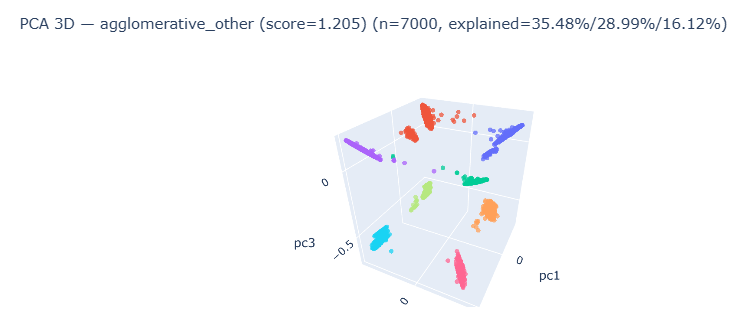  
*Figure 2: 3D Visualisation Using PCA*


##### Manifold Structure (t-SNE)

t-SNE was applied to a subsample of 7,000 observations with a perplexity of 30, focusing on preserving local neighborhood probabilities in a two-dimensional non-linear embedding. In contrast to the PCA projection, the t-SNE map reveals distinct, compact point clouds corresponding to the identified clusters, with clear gaps and well-defined boundaries between them. This separation indicates that the observed overlap in the linear PCA space is primarily an artifact of projecting a high-dimensional manifold into a low-dimensional linear space, rather than evidence of genuine similarity between clusters. The t-SNE results therefore support the interpretation that the clusters correspond to real, structurally distinct regions of the high-dimensional manifold and that non-linear methods are necessary to fully expose and exploit this separability.

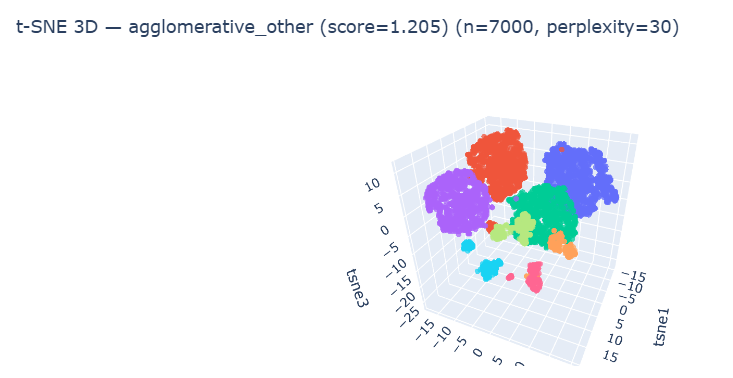  
*Figure 3: 3D Visualisation Using t-SNE*


### Matching Products to Clusters

The final Agglomerative Clustering model identified **8 clusters**, which were subsequently grouped into **4 personas**, each linked to a specific strategic financial state. The grouping is based on shared asset and liability profiles, while differences in responsiveness levels within each persona are handled by adjusting the offer terms—specifically adding extra benefits for low-responsiveness customers to maximize conversion. The cluster-persona matching was performed through domain knowledge in the banking field and previous research. 

**The first persona** combines cluster 0 (high responsiveness) and cluster 1 (low responsiveness). Clients in both clusters are "Leveraged Borrowers" who hold both active loans and significant deposits. This indicates an inefficient capital structure where they pay high interest on unsecured debt while simultaneously holding idle cash. For this segment, the recommended product is **Priority Secured Refinance**, which leverages their savings as collateral to drastically lower their interest rate. Cluster 1, being passive, requires an additional tangible incentive in the form of an immediate cash bonus to overcome inertia.

**The second persona** merges cluster 6 (high responsiveness) and cluster 3 (low responsiveness). Both clusters are characterized as "Pure Borrowers" having active loans but no deposit relationship, often maximizing their borrowing power. This profile suggests financial stress and a need for immediate cash flow relief. The recommended product is **Streamline Consolidation Loan**, designed to simplify multiple debts into a single, lower fixed payment. For cluster 3, the offer is structured as an **Essential Relief Loan**, which waives origination fees and defers the first payment to build trust with skeptical, low-response users.

**The third persona** consists of cluster 5 (high responsiveness) and cluster 2 (low responsiveness). These clients are "Pure Savers" who have deposits and unused borrowing power but no active loans. They represent the bank's stable asset base. For the active, high-spending clients in cluster 5, the recommendation is the **Prestige Cash Rewards Visa** to capture transaction volume. For the passive clients in cluster 2, the strategy shifts to retention via **Preferred Savings Select**, offering a temporary interest rate boost to prevent capital attrition.

**The fourth persona** has cluster 7 (high responsiveness) and cluster 4 (low responsiveness). These clients are "Blank Slates" with high borrowing power but currently no loans and no deposits, making them prime acquisition targets. For the eager clients in cluster 7, the recommended product is **Personal Credit Line**, offering on-demand liquidity for consumption. Cluster 4, which is risk-averse and unresponsive, is offered **Confidence Checking**, utilizing fee-free overdraft protection as a low-barrier entry point to build a banking relationship.

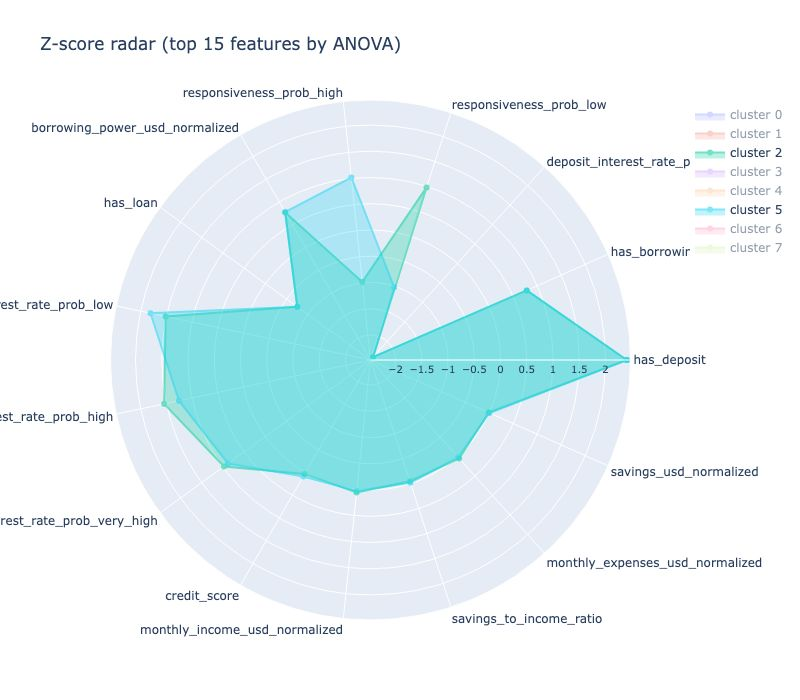  
*Figure 4: Z-Score radar plot for Clusters 2 and 5*

                                                                                                                                                                                                                                                                                                                         

## Recommendation Evaluation with an LLM Agent

Classical clustering metrics such as silhouette score quantify how well clusters are separated in feature space, but they do not directly answer the key business question: does this segmentation lead to better product–customer matches? To obtain a more realistic, user‑centric evaluation without running an expensive and time‑consuming field experiment with real customers, the project employs a Large Language Model (LLM) agent to mimic client behaviour and preferences in response to the proposed product allocations. Inspired by frameworks such as Agent4Rec, where LLM‑based agents simulate user reactions in recommender systems, the LLM in this project is provided with a concise description of the client type, cluster profile and key financial indicators and the details of the recommended banking product.  

The LLM agent utilizes the `gpt-oss-120b` model with low temperature (0.1) for consistent outputs. It operates through a two-part prompt: a system context defining the agent's role as a banking customer simulator focused on product value assessment, and a user content section containing batch customer profiles and product details. The agent then returns three outputs for each test case: ***(i) an acceptance decision*** (yes/no) indicating whether the client is likely to take the offer, ***(ii) satisfaction rating*** on a 1-10 scale, and ***(iii) profile fit score*** on a 1-10 scale, how well the product matches the user's financial profile/goals.

The evaluation is structured to compare **cluster‑based recommendations against random product assignment**. For each cluster, multiple evaluation rounds are run: in each round, a sample of 30 clients is drawn from the cluster, and for each client the LLM is asked to assess the recommended product for that cluster given the client’s financial persona. This yields an empirical distribution of simulated acceptance and satisfaction outcomes under the cluster‑based strategy. In a separate set of experiments, 30 clients are again sampled, each client is assigned a random product, rather than the cluster‑matched one, and the same LLM evaluation procedure is applied. By aggregating and comparing acceptance rates and average satisfaction scores across many such samples, the project can quantify whether the clustering‑driven recommendation policy provides a measurable advantage over a random allocation of products. This setup allows the system to be assessed not only in terms of internal cluster structure but also in terms of simulated user outcomes, providing an evaluation that is more closely aligned with real‑world decision quality while remaining feasible within the scope of an academic project.

Since LLM inference is costly in terms of time and compute resources, the evaluation employs **bootstrap sampling** to quantify the uncertainty around the simulated outcomes.The project utilized a studentized bootstrap confidence interval, using 1000 bootstrap samples and 200 iterations. This procedure provides empirical confidence intervals for satisfaction scores, profile‑fit scores, and acceptance rates, allowing the analysis to distinguish stable effects of the cluster‑based policy from variations that may arise due to sampling noise.


##### LLM Evaluation with **Clustering** Product-persona Matching

When recommendations are generated using the clustering-based matching strategy, the distributions shift toward more favourable outcomes. The global average satisfaction scores concentrate at higher values, with a mean of 7.45 (CI: 7.36, 7.53) and tightly peaked histogram, suggesting consistently well perceived value across clients. Profile fit scores have a mean of 7.38 (CI: 7.26, 7.49) and with a narrow  distribution, indicating that products are systematically aligned with the financial profiles and products in each cluster persona. The acceptance-rate distribution leans toward the upper end of the scale. The vast majority of scenarios achieve acceptance rate of 1 with mean of 95.6% (CI: 94.12, 96.88), the mean acceptance rate climbs to about 95.6%, implying that cluster-informed recommendations are highly likely to be followed through by the simulated clients.
  

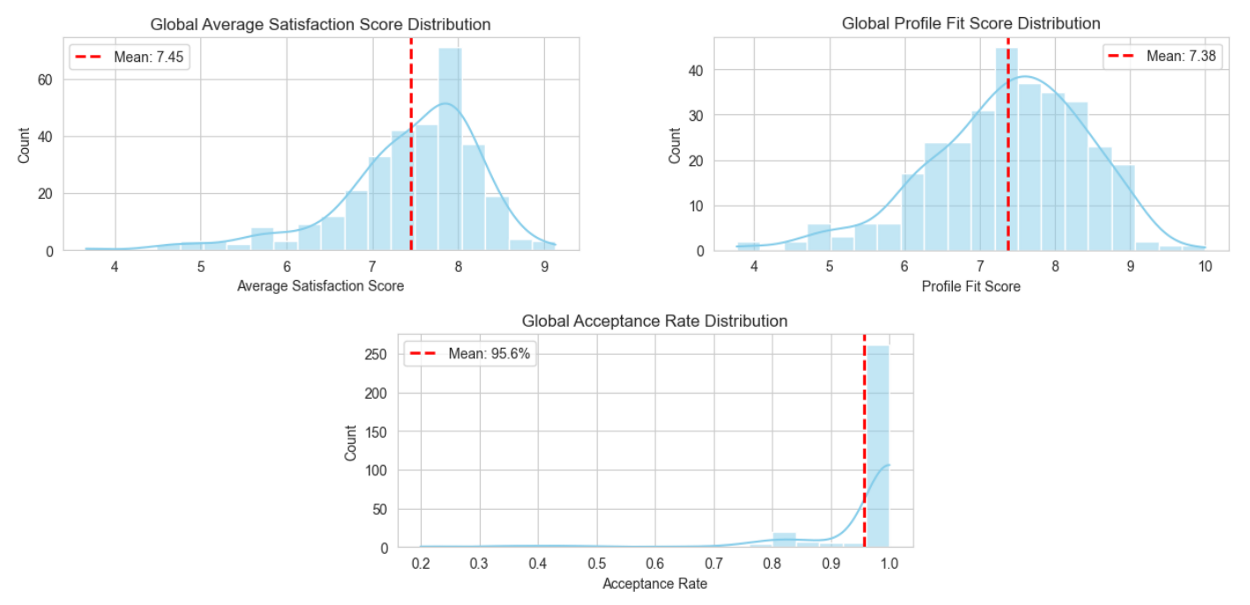  
*Figure 5: LLM Evaluation for Clustered Data*


##### LLM Evaluation with **Random** Product-persona Matching  

Under the random product–persona matching baseline, the LLM evaluation yields moderately positive but widely dispersed outcomes for both satisfaction and profile fit scores. The global distribution of average satisfaction scores centers around a mean of approximately 6.1 (CI: 5.82, 6.31), with substantial spread and a visible tail toward lower ratings, indicating that many random matches deliver only mediocre perceived value. Similarly, profile fit scores cluster around a mean close to 6.0 (CI: 5.81, 6.25), again with broad variability that reflects frequent mismatches between products and client profiles. The acceptance-rate distribution is particularly heterogeneous: while some offers are accepted at relatively high rates, a large mass lies around 40–60%, and many scenarios exhibit very low acceptance, producing an overall mean acceptance rate of about 68% (CI: 63.11, 73.22), which shows that random allocation often fails to convince the simulated clients.


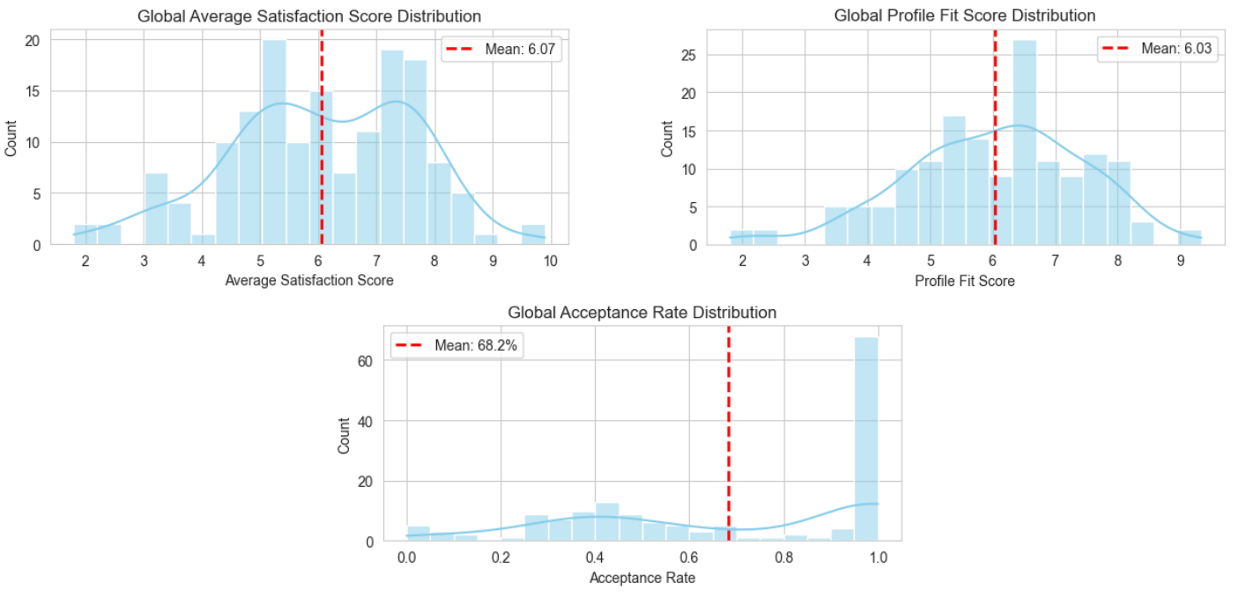  
*Figure 6: LMM Evaluation for Random Allocation*


Comparing the two conditions, the clustering algorithm yields higher means and lower dispersion for satisfaction and profile fit scores, together with a significant increase in acceptance rates relative to random assignment. In terms of the core business problem, the LLM-based evaluation provides strong evidence that the clustering-driven strategy is substantially better than random allocation. It produces more relevant offers, higher expressed satisfaction, and a much greater likelihood of acceptance, suggesting that the learned segments capture meaningful structure that can be exploited for more effective personalized banking recommendations.


## Conclusion

The empirical results show that clustering‑based segmentation uncovers distinct client personas with coherent financial characteristics and product needs. By leveraging engineered behavioural indicators such as responsiveness rate and borrowing power, the model produces segments that align closely with interpretable banking segments, including risk‑averse savers, credit‑constrained borrowers, and high‑engagement deposit holders. Internal validation and dimensionality‑reduction visualisations support that these groups create meaningful cloud points of the high‑dimensional feature space rather than being artefacts of noise. The cluster‑based recommendation maps each cluster to a small set of banking products which are best suited for each client persona depending on their spending, saving, and borrowing behaviour.

The LLM‑based evaluation framework then provides a user‑centric perspective on the effectiveness of the cluster‑based recommendations. By simulating client personas and eliciting acceptance decisions, satisfaction scores, and profile‑fit assessments, the agent allows the system to be assessed in perceived relevance rather than solely geometric separation in feature space. When comparing cluster‑based matching to random allocation, the simulated outcomes consistently favour the clustered strategy, with higher average satisfaction, improved profile fit, and markedly higher acceptance rates across repeated evaluation rounds. These results indicate that unsupervised segmentation with  interpretable product‑assignment rules can significantly improve the quality of product–customer matching. The project illustrates how classical clustering, feature engineering, and LLM frameworks can work together in a single pipeline that links quantitative modelling with qualitative evaluation.

**Limitations of the project** is an important factor for further study considerations. Clients' financial profiles are derived from synthetic and combined datasets, which may not fully represent the complexity, heterogeneity, and regulatory constraints of real bank clients. The LLM agent, inspired by Agent4Rec, is an offline simulator whose preferences and acceptance behaviour are driven by prompts and model priors rather than observed customer histories. Additionally, the project lacks rejection analysis of the LLM evaluation. Future work could therefore incorporate real transaction and product‑usage data, explore alternative clustering methods or representation learning approaches to capture more nuanced financial behaviours. Extending the evaluation to include fairness, stability over time, and robustness to economic shocks would further strengthen the practical relevance of the proposed bank product recommendation framework.
  
  

  


  
## References

<span style="color:gray; font-style:italic"> ["Personal Finance ML Dataset, Arif Miah, Kaggle, 2025"](https://www.kaggle.com/datasets/miadul/personal-finance-ml-dataset)</span>  

<span style="color:gray; font-style:italic"> ["Customer Segmentation Using K-Means Clustering for Targeted Marketing in Banking, Karthika Gopalakrishnan, International Journal of Artificial Intelligence & Machine Learning (IJAIML), 2024"](https://www.researchgate.net/publication/389352556_Customer_Segmentation_Using_K-Means_Clustering_for_Targeted_Marketing_in_Banking)</span>  

<span style="color:gray; font-style:italic"> ["Application of Cluster Analysis in Optimizing Financial Product Recommendation System, Ni Rui, Hong Kong Baptist University, 2025"](https://direct.ewa.pub/proceedings/aemps/article/view/22678/pdf)</span>  

<span style="color:gray; font-style:italic"> ["Customer-specific Product Recommendation based on Financial Performance, Prachi Umesh Shah, Uppsala University, 2024"](http://www.diva-portal.org/smash/get/diva2:1898111/FULLTEXT01.pdf)</span>  

<span style="color:gray; font-style:italic"> ["On Generative Agents in Recommendation, An Zhang, Yuxin Chen, Leheng Sheng, Xiang Wang, Tat-Seng Chua, arXiv, 2023"](https://arxiv.org/abs/2310.10108)</span>  
